In [ ]:
!pip install lightgbm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from lightgbm import LGBMClassifier

In [5]:
import os

folders = [
    "data",
    "notebooks",
    "outputs",
    "figures",
    "figures/eda_plots",
    "figures/model_plots",
    "models",
    "presentation_notes"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folder structure created successfully.")


Folder structure created successfully.


In [7]:
train = pd.read_csv("data/dataset_C_training.csv")
test = pd.read_csv("data/dataset_C_testing.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())
display(test.head())

Train shape: (4756, 31)
Test shape: (4749, 30)


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,0,4,2,2.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,"MSA, Not Principle City",0.0,0.0,0,2,3,2.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,0,3,2,2.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Employed,Non-MSA,1.0,0.0,0,4,4,1.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,Non-MSA,0.0,0.0,0,3,2,1.0,wholesale


In [8]:
target = "covid_vaccine"
id_col = "respondent_id"

X = train.drop(columns=[target, id_col])
y = train[target]

X_test_final = test.drop(columns=[id_col])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test_final shape:", X_test_final.shape)

X shape: (4756, 29)
y shape: (4756,)
X_test_final shape: (4749, 29)


In [11]:
train_path = "data/dataset_C_training.csv"
test_path = "data/dataset_C_testing.csv"
submission_path = "data/dataset_C_example_submission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())
display(test.head())

Train shape: (4756, 31)
Test shape: (4749, 30)


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,0,4,2,2.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,NaN,NaN,"MSA, Not Principle City",0.0,0.0,0,2,3,2.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,0,3,2,2.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Employed,Non-MSA,1.0,0.0,0,4,4,1.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,Non-MSA,0.0,0.0,0,3,2,1.0,wholesale


In [12]:
print("Missing values in training data:")
display(X.isnull().sum().sort_values(ascending=False))

print("Target distribution:")
display(y.value_counts())
display(y.value_counts(normalize=True))

Missing values in training data:


,0
employment_sector,2330
health_insurance,1908
income_poverty,748
rent_or_own,329
employment_status,238
marital_status,231
education,228
chronic_med_condition,169
child_under_6_months,135
health_worker,132


Target distribution:


,count
covid_vaccine,
0,3202
1,1554


,proportion
covid_vaccine,
0,0.673255
1,0.326745


In [13]:
ordinal_cols = [
    "age_group",
    "education",
    "income_poverty"
]

nominal_cols = [
    "race",
    "sex",
    "marital_status",
    "rent_or_own",
    "employment_status",
    "census_msa",
    "employment_sector"
]

numeric_cols = [col for col in X.columns if col not in ordinal_cols + nominal_cols]

print("Numeric columns:", numeric_cols)
print("Ordinal columns:", ordinal_cols)
print("Nominal columns:", nominal_cols)

Numeric columns: ['covid_concern', 'covid_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'household_adults', 'household_children', 'doctor_recc_covid', 'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc']
Ordinal columns: ['age_group', 'education', 'income_poverty']
Nominal columns: ['race', 'sex', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [14]:
age_order = [
    "18 - 34 Years",
    "35 - 44 Years",
    "45 - 54 Years",
    "55 - 64 Years",
    "65+ Years"
]

education_order = [
    "< 12 Years",
    "12 Years",
    "Some College",
    "College Graduate"
]

income_order = [
    "Below Poverty",
    "<= $75,000, Above Poverty",
    "> $75,000"
]

In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=[age_order, education_order, income_order],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("ord", ordinal_transformer, ordinal_cols),
        ("nom", nominal_transformer, nominal_cols)
    ]
)

In [16]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (3804, 29)
X_valid: (952, 29)


In [17]:
lgbm_model = Pipeline(steps=[
    ("preprocessor", preprocessor_lgbm),
    ("classifier", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42
    ))
])

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1243, number of negative: 2561
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 137
[LightGBM] [Info] Number of data points in the train set: 3804, number of used features: 56
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['covid_concern',
                                                   'covid_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral_outside_home',
                                                   'behavioral_touch_face',
                                                   'ch...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['race', 'sex',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'census_msa',
                                                   'employment_sector'])])),
                ('classifier',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
                                learning_rate=0.03, n_estimators=500,
                                random_state=42, subsample=0.8))])

In [18]:
valid_probs = lgbm_model.predict_proba(X_valid)[:, 1]
valid_preds = (valid_probs >= 0.5).astype(int)

print("LightGBM Results")
print("Accuracy:", accuracy_score(y_valid, valid_preds))
print("F1 Score:", f1_score(y_valid, valid_preds))
print("ROC-AUC:", roc_auc_score(y_valid, valid_probs))
print(classification_report(y_valid, valid_preds))

LightGBM Results
Accuracy: 0.7699579831932774
F1 Score: 0.6604651162790698
ROC-AUC: 0.8144779810485023
              precision    recall  f1-score   support

           0       0.84      0.81      0.83       641
           1       0.64      0.68      0.66       311

    accuracy                           0.77       952
   macro avg       0.74      0.75      0.74       952
weighted avg       0.77      0.77      0.77       952



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


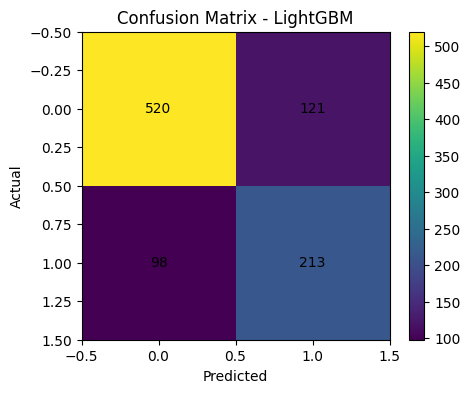

In [19]:
cm = confusion_matrix(y_valid, valid_preds)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - LightGBM")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.savefig("figures/model_plots/lightgbm_confusion_matrix.png", bbox_inches="tight")
plt.show()

In [20]:
test_probs = lgbm_model.predict_proba(X_test_final)[:, 1]

LightGBMValues = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "covid_vaccine": test_probs
})

LightGBMValues.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,respondent_id,covid_vaccine
0,4757,0.435016
1,4758,0.195523
2,4759,0.205312
3,4760,0.493454
4,4761,0.048805


In [21]:
LightGBMValues.to_csv("outputs/LightGBMValues.csv", index=False)

print("LightGBMValues.csv saved successfully")

LightGBMValues.csv saved successfully


In [22]:
pd.read_csv("outputs/LightGBMValues.csv").head()

,respondent_id,covid_vaccine
0,4757,0.435016
1,4758,0.195523
2,4759,0.205312
3,4760,0.493454
4,4761,0.048805


In [23]:
!ls outputs

LightGBMValues.csv


In [24]:
!git status
!git add .
!git commit -m "Initial hackathon project setup with folder structure"


fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [25]:
from getpass import getpass

username = "ajaynunna"
token = getpass("Paste GitHub token: ")

repo_url = "https://github.com/Research-Methods-hackathon/Hackathon_GroupV"
auth_repo_url = repo_url.replace("https://", f"https://{username}:{token}@")

!git remote set-url origin {auth_repo_url}
!git push origin main

!git remote set-url origin https://github.com/Research-Methods-hackathon/Hackathon_GroupV

Paste GitHub token: ··········
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
